In [3]:
# PREPARAÇÂO E MERGE DE DADOS

import pandas
import numpy as np
import matplotlib.pyplot as plt

crimes = pandas.read_csv(r"C:\Users\Aluno.SantaLuzia\Documents\Elaine\uc2\bases\03.BaseDPEvolucaoMensalCisp.csv", sep=';', encoding='iso-8859-1')
delegacias = pandas.read_csv(r"C:\Users\Aluno.SantaLuzia\Documents\Elaine\uc2\bases\08.DP.csv")

crimesJoinDelegacias = pandas.merge(crimes, delegacias, right_on='codDP', left_on='cisp')
crimes_delegacias = crimesJoinDelegacias[['nome', 'mes', 'ano', 'mes_ano', 'roubo_celular', 'roubo_transeunte', 'munic']]

In [13]:
# DIAGNÓSTICO ESTATÍSTICO

def diagnostico(df, coluna):
    media = df[coluna].mean()
    mediana = df[coluna].median()

    moda = df[coluna].mode().iloc[0]
    desvio = df[coluna].std()
    variancia = df[coluna].var()
    cv = (desvio / media) * 100 if media != 0 else np.nan
    minimo = df[coluna].min()
    maximo = df[coluna].max()
    amplitude = maximo - minimo
    q1 = df[coluna].quantile(0.25)
    q2 = df[coluna].quantile(0.50)
    q3 = df[coluna].quantile(0.75)
    iqr = q3 - q1

    li = q1 - 1.5*iqr
    ls = q3 + 1.5*iqr

    assimetria = df[coluna].skew()
    curtose = df[coluna].kurt()

    print(f"Diagnóstico Estatístico de {coluna}\n")
    print(f"Média: {media:.2f}")
    print(f"Mediana: {mediana:.2f}")
    print(f"Moda: {moda}")
    print(f"Desvio padrão: {desvio:.2f}")
    print(f"Variância: {variancia:.2f}")
    print(f"CV: {cv:.2f}%")
    print(f"Mínimo: {minimo}")
    print(f"Máximo: {maximo}")
    print(f"Amplitude: {amplitude}")
    print(f"Q1: {q1}")
    print(f"Q2: {q2}")
    print(f"Q3: {q3}")
    print(f"IQR: {iqr}")
    print(f'Limite superior = {ls:.2f}')
    print(f'Limite inferior = {li:.2f}')
    print(f"Assimetria: {assimetria:.2f}")
    print(f"Curtose: {curtose:.2f}")

    print("[Média vs Mediana]: ")
    if np.isclose(media, mediana, rtol=0.05):
        print(" Distribuição equilibrada. Média e mediana são muito próximas.")
    elif media > mediana:
        print(" Possível cauda longa à direita. Valores altos isolados puxam a média para cima.")
    else:
        print(" Possível cauda longa à esquerda. Valores baixos isolados puxam a média para baixo.")

    print("[Assimetria]:")
    if np.isclose(assimetria, 0, atol=0.1):
        print("Distribuição perfeitamente simétrica (ou muito próxima disso).")
    elif assimetria > 0:
        print("Assimetria positiva (à direita). A cauda direita é mais longa ou grossa.")
    else:
        print("Assimetria negativa (à esquerda). A cauda esquerda é mais longa ou grossa.")
        
    print("[Curtose]:")
    if np.isclose(curtose, 0, atol=0.1):
        print("Caudas e pico semelhantes aos de uma distribuição Normal.")
    elif curtose > 0:
        print("Caudas pesadas e pico mais acentuado. Indica maior presença de outliers.")
    else:
        print("Caudas leves e pico mais achatado. Dados mais espalhados e menos outliers.")

    return df[df[coluna] > ls]


In [14]:
# IDENTIFICAÇÃO DE OUTLIERS

outliers_celular = diagnostico(crimes_delegacias, "roubo_celular")

Diagnóstico Estatístico de roubo_celular

Média: 7.98
Mediana: 2.00
Moda: 0
Desvio padrão: 13.53
Variância: 182.98
CV: 169.50%
Mínimo: 0
Máximo: 205
Amplitude: 205
Q1: 0.0
Q2: 2.0
Q3: 11.0
IQR: 11.0
Limite superior = 27.50
Limite inferior = -16.50
Assimetria: 3.37
Curtose: 18.77
[Média vs Mediana]: 
 Possível cauda longa à direita. Valores altos isolados puxam a média para cima.
[Assimetria]:
Assimetria positiva (à direita). A cauda direita é mais longa ou grossa.
[Curtose]:
Caudas pesadas e pico mais acentuado. Indica maior presença de outliers.


In [6]:
outliers_celular

,nome,mes,ano,mes_ano,roubo_celular,roubo_transeunte,munic
0,001ª DP - Praça da República,1,2003,2003m01,32,26,Rio de Janeiro
2,005ª DP - Mem de Sá,1,2003,2003m01,34,26,Rio de Janeiro
16,021ª DP - Bonsucesso,1,2003,2003m01,31,52,Rio de Janeiro
18,023ª DP - Méier,1,2003,2003m01,41,32,Rio de Janeiro
24,029ª DP - Madureira,1,2003,2003m01,29,39,Rio de Janeiro
...,...,...,...,...,...,...,...
34698,056ª DP - Comendador Soares,7,2024,2024m07,44,49,Nova Iguaçu
34700,058ª DP - Posse,7,2024,2024m07,44,84,Nova Iguaçu
34701,059ª DP - Duque de Caxias,7,2024,2024m07,80,148,Duque de Caxias
34702,060ª DP - Campos Elíseos,7,2024,2024m07,43,24,Duque de Caxias


In [7]:
outliers_celular.groupby("nome")["mes_ano"].count().sort_values(ascending=False)

nome
059ª DP - Duque de Caxias             174
034ª DP - Bangu                       119
029ª DP - Madureira                   113
023ª DP - Méier                       109
027ª DP - Vicente de Carvalho         104
064ª DP - São João de Meriti          103
033ª DP - Realengo                     98
052ª DP - Nova Iguaçu                  95
035ª DP - Campo Grande                 90
054ª DP - Belford Roxo                 83
021ª DP - Bonsucesso                   83
058ª DP - Posse                        81
039ª DP - Pavuna                       81
005ª DP - Mem de Sá                    76
018ª DP - Praça da Bandeira            75
032ª DP - Taquara                      74
056ª DP - Comendador Soares            73
057ª DP - Nilópolis                    61
038ª DP - Brás de Pina                 55
074ª DP - Alcântara                    54
031ª DP - Ricardo de Albuquerque       52
009ª DP - Catete                       49
072ª DP - São Gonçalo                  48
016ª DP - Barra da Tijuca    

In [8]:
outliers_transeunte = diagnostico(crimes_delegacias, "roubo_transeunte")

Diagnóstico Estatístico de roubo_transeunte

Média: 35.00
Mediana: 11.00
Moda: 0
Desvio padrão: 51.03
Variância: 2604.35
CV: 145.83%
Mínimo: 0
Máximo: 504
Amplitude: 504
Q1: 0.0
Q2: 11.0
Q3: 53.0
IQR: 53.0
Limite superior = 132.50
Limite inferior = -79.50
Assimetria: 2.37
Curtose: 7.77
[Média vs Mediana]: 
 Possível cauda longa à direita. Valores altos isolados puxam a média para cima.
[Assimetria]:
Assimetria positiva (à direita). A cauda direita é mais longa ou grossa.
Caudas pesadas e pico mais acentuado. Indica maior presença de outliers.


In [9]:
outliers_transeunte

,nome,mes,ano,mes_ano,roubo_celular,roubo_transeunte,munic
3364,023ª DP - Méier,3,2005,2005m03,35,138,Rio de Janeiro
3395,059ª DP - Duque de Caxias,3,2005,2005m03,35,136,Duque de Caxias
3624,023ª DP - Méier,5,2005,2005m05,25,173,Rio de Janeiro
3785,059ª DP - Duque de Caxias,6,2005,2005m06,22,159,Duque de Caxias
4045,059ª DP - Duque de Caxias,8,2005,2005m08,42,142,Duque de Caxias
...,...,...,...,...,...,...,...
33879,059ª DP - Duque de Caxias,1,2024,2024m01,73,149,Duque de Caxias
33967,005ª DP - Mem de Sá,2,2024,2024m02,201,164,Rio de Janeiro
34153,059ª DP - Duque de Caxias,3,2024,2024m03,68,154,Duque de Caxias
34432,064ª DP - São João de Meriti,5,2024,2024m05,26,137,São João de Meriti


In [10]:
correlacao = crimes_delegacias[['roubo_celular','roubo_transeunte']].corr()

r = correlacao.loc["roubo_celular", "roubo_transeunte"]

print(f"Coeficiente de correlação (Pearson): {r:.3f}")

if abs(r) > 0.7:
    intensidade = "forte"
elif abs(r) > 0.4:
    intensidade = "moderada"
else:
    intensidade = "fraca"

if r > 0:
    print(f"Existe uma correlação linear positiva {intensidade}.")
    print("Quando o roubo a transeunte aumenta, o roubo de celular tende a aumentar também.")
elif r < 0:
    print(f"Existe uma correlação linear negativa {intensidade}.")
    print("Quando o roubo a transeunte aumenta, o roubo de celular tende a diminuir.")
else:
    print("Não existe correlação linear entre as variáveis.")

Coeficiente de correlação (Pearson): 0.715
Existe uma correlação linear positiva forte.
Quando o roubo a transeunte aumenta, o roubo de celular tende a aumentar também.


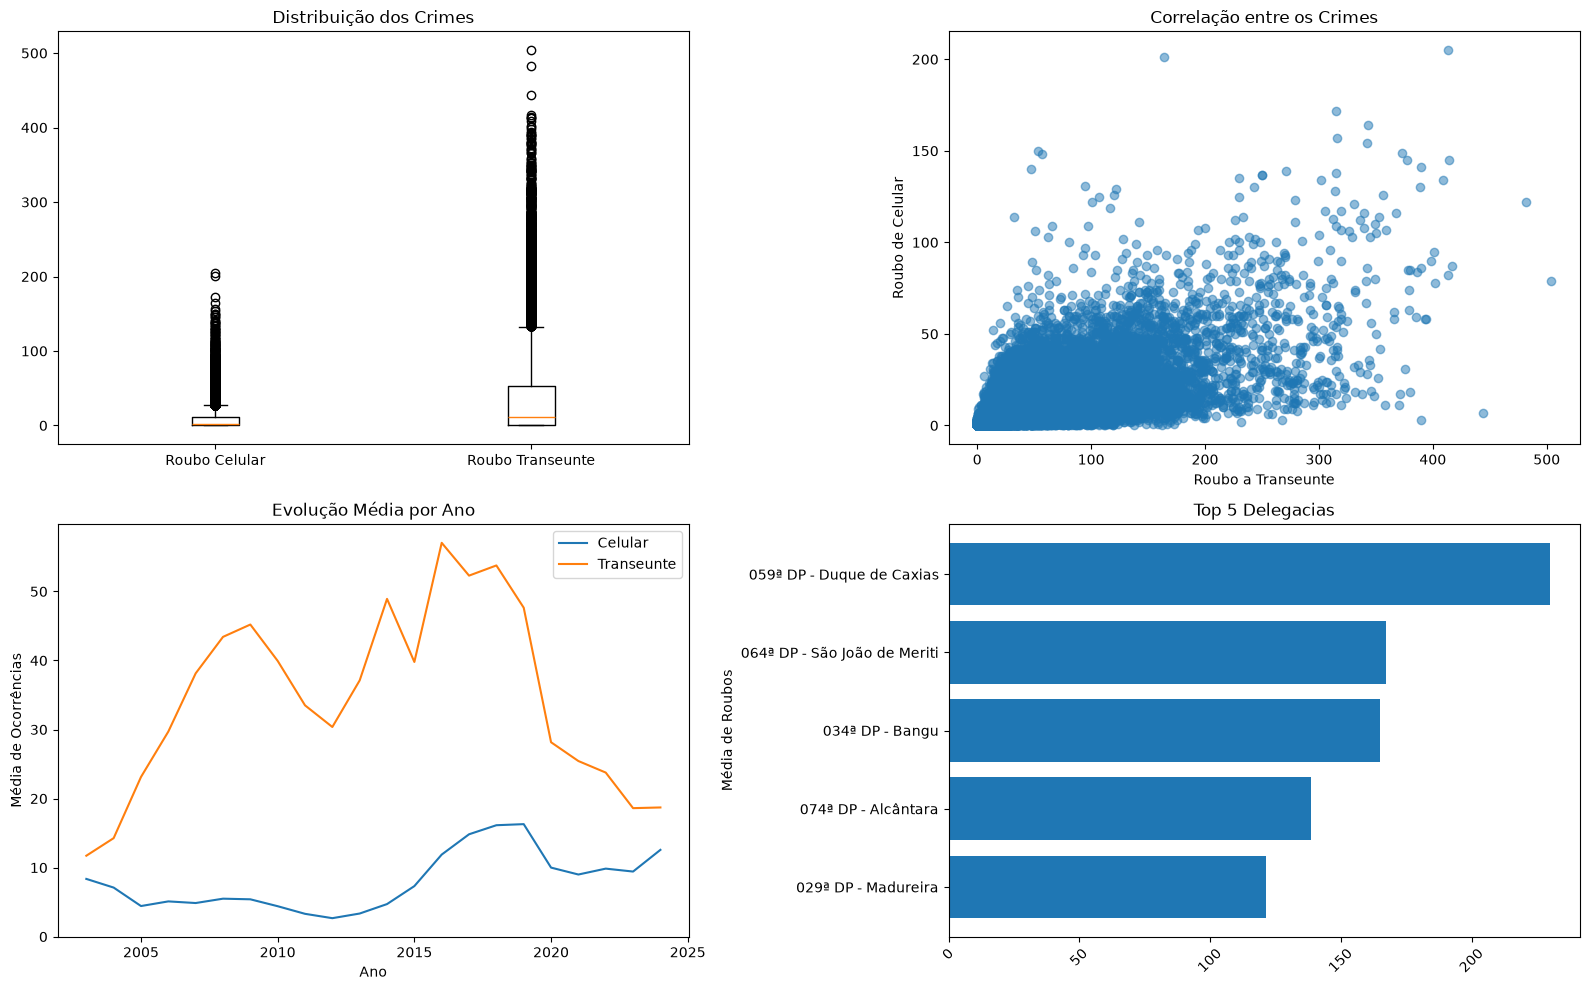

In [ ]:
# VISUALIZAÇÃO DE DADOS

fig, ax = plt.subplots(2, 2, figsize=(16, 10))

# plt.subplot(2,2,1)

ax[0,0].boxplot([
    crimes_delegacias["roubo_celular"],
    crimes_delegacias["roubo_transeunte"]
])

ax[0,0].set_xticklabels([
    "Roubo Celular",
    "Roubo Transeunte"
])

ax[0,0].set_title("Distribuição dos Crimes")


ax[0,1].scatter(
    crimes_delegacias["roubo_transeunte"],
    crimes_delegacias["roubo_celular"],
    alpha=0.5
)

ax[0,1].set_xlabel("Roubo a Transeunte")
ax[0,1].set_ylabel("Roubo de Celular")
ax[0,1].set_title("Correlação entre os Crimes")


serie = (
    crimes_delegacias
    .groupby("ano")[["roubo_celular","roubo_transeunte"]]
    .mean()
)

ax[1,0].plot(
    serie.index,
    serie["roubo_celular"],
    label="Celular"
)

ax[1,0].plot(
    serie.index,
    serie["roubo_transeunte"],
    label="Transeunte"
)

ax[1,0].set_title("Evolução Média por Ano")
ax[1,0].set_xlabel("Ano")
ax[1,0].set_ylabel("Média de Ocorrências")
ax[1,0].legend()


top5 = (
    crimes_delegacias
    .groupby("nome")["roubo_transeunte"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

ax[1,1].barh(top5.index, top5.values)
ax[1,1].invert_yaxis()

ax[1,1].set_title("Top 5 Delegacias")
ax[1,1].set_ylabel("Média de Roubos")
ax[1,1].tick_params(axis="x", rotation=45)


plt.tight_layout()
plt.show()